In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 整理好的数据
data = [
    # dataset, reranker, n, retriever, type, setting, k, model
    ["scifact", "None", "3", "bge-large-en-v1.5", "smlty", "0.5", "3", "Qwen2.5-14B-Instruct", 156, 380.89, 259, 351, 427, 231, 327, 499, 953, 0.92619, 0.844],
    ["scifact", "None", "3", "bge-large-en-v1.5", "smlty", "0.5", "10", "Qwen2.5-14B-Instruct", 165, 373.64, 268, 351, 430, 229, 324, 499, 950, 0.9263, 0.8434],
    ["scifact", "None", "3", "bge-large-en-v1.5", "smlty", "0.5", "20", "Qwen2.5-14B-Instruct", 161, 374.53, 269, 352, 439, 232, 328, 499, 950, 0.9261, 0.8434],

    ["scifact", "bge-reranker-large", "3", "bge-large-en-v1.5", "smlty", "0.5", "3", "Qwen2.5-14B-Instruct", 160, 371.89, 267, 351, 451, 222, 321, 499, 957, 0.9266, 0.8442],
    ["scifact", "bge-reranker-large", "3", "bge-large-en-v1.5", "smlty", "0.5", "10", "Qwen2.5-14B-Instruct", 168, 378.82, 293, 359, 464, 244, 351, 499, 957, 0.9269, 0.841],
    ["scifact", "bge-reranker-large", "3", "bge-large-en-v1.5", "smlty", "0.5", "20", "Qwen2.5-14B-Instruct", 181, 388.54, 315, 365, 482, 239, 359, 499, 956, 0.9264, 0.8391],

    ["scifact", "None", "3", "bge-large-en-v1.5", "mmr", "40", "3", "Qwen2.5-14B-Instruct", 170, 315.2, 253, 366, 413, 246, 313, 500, 680, 0.9246, 0.7779],
    ["scifact", "None", "3", "bge-large-en-v1.5", "mmr", "40", "10", "Qwen2.5-14B-Instruct", 165, 336.41, 263, 361, 424, 237, 312, 499, 910, 0.9246, 0.8121],
    ["scifact", "None", "3", "bge-large-en-v1.5", "mmr", "40", "20", "Qwen2.5-14B-Instruct", 163, 373.8, 281, 346, 461, 239, 353, 500, 945, 0.9238, 0.8285],
    ["scifact", "None", "3", "bge-large-en-v1.5", "mmr", "40", "30", "Qwen2.5-14B-Instruct", 156, 371.54, 259, 349, 429, 224, 311, 200, 954, 0.9242, 0.8364],

    ["scifact", "bge-reranker-large", "3", "bge-large-en-v1.5", "mmr", "40", "3", "Qwen2.5-14B-Instruct", 170, 321.13, 264, 366, 421, 250, 334, 499, 699, 0.9226, 0.7792],
    ["scifact", "bge-reranker-large", "3", "bge-large-en-v1.5", "mmr", "40", "10", "Qwen2.5-14B-Instruct", 172, 337.78, 273, 366, 461, 259, 364, 500, 888, 0.9239, 0.8054],
    ["scifact", "bge-reranker-large", "3", "bge-large-en-v1.5", "mmr", "40", "20", "Qwen2.5-14B-Instruct", 170, 362.36, 285, 358, 454, 250, 349, 500, 920, 0.9238, 0.8203],
    ["scifact", "bge-reranker-large", "3", "bge-large-en-v1.5", "mmr", "40", "30", "Qwen2.5-14B-Instruct", 172, 391.19, 301, 359, 464, 237, 348, 500, 954, 0.9244, 0.8275],

    ["scifact", "None", "3", "all-mpnet-base-v2", "smlty", "0.1", "3", "Qwen2.5-14B-Instruct", 176, 377.09, 302, 344, 475, 240, 373, 475, 586, 0.8746, 0.7203],
    ["scifact", "None", "3", "all-mpnet-base-v2", "smlty", "0.1", "10", "Qwen2.5-14B-Instruct", 170, 379.36, 292, 347, 481, 242, 379, 468, 578, 0.8735, 0.7203],
    ["scifact", "None", "3", "all-mpnet-base-v2", "smlty", "0.1", "20", "Qwen2.5-14B-Instruct", 168, 387.28, 293, 335, 485, 243, 381, 469, 584, 0.8737, 0.7201],

    ["scifact", "ms-marco-MiniLM-L6-v2", "3", "all-mpnet-base-v2", "smlty", "0.1", "3", "Qwen2.5-14B-Instruct", 179, 378.3, 308, 349, 455, 231, 358, 477, 581, 0.8799, 0.7198],
    ["scifact", "ms-marco-MiniLM-L6-v2", "3", "all-mpnet-base-v2", "smlty", "0.1", "10", "Qwen2.5-14B-Instruct", 169, 378.41, 296, 340, 442, 238, 346, 481, 550, 0.8778, 0.7121],
    ["scifact", "ms-marco-MiniLM-L6-v2", "3", "all-mpnet-base-v2", "smlty", "0.1", "20", "Qwen2.5-14B-Instruct", 179, 379.63, 313, 356, 469, 245, 366, 488, 542, 0.8794, 0.7049],

    ["scifact", "None", "3", "all-mpnet-base-v2", "mmr", "40", "3", "Qwen2.5-14B-Instruct", 182, 345.03, 291, 380, 471, 269, 366, 449, 359, 0.8573, 0.5714],
    ["scifact", "None", "3", "all-mpnet-base-v2", "mmr", "40", "10", "Qwen2.5-14B-Instruct", 205, 370.74, 340, 382, 494, 275, 404, 468, 439, 0.8731, 0.6546],
    ["scifact", "None", "3", "all-mpnet-base-v2", "mmr", "40", "20", "Qwen2.5-14B-Instruct", 166, 352.67, 293, 349, 481, 233, 381, 469, 527, 0.8733, 0.6941],
    ["scifact", "None", "3", "all-mpnet-base-v2", "mmr", "40", "30", "Qwen2.5-14B-Instruct", 168, 392.02, 303, 344, 481, 244, 375, 474, 563, 0.873, 0.7135],

    ["scifact", "ms-marco-MiniLM-L6-v2", "3", "all-mpnet-base-v2", "mmr", "40", "3", "Qwen2.5-14B-Instruct", 177, 348.06, 288, 373, 457, 265, 362, 447, 372, 0.8558, 0.5746],
    ["scifact", "ms-marco-MiniLM-L6-v2", "3", "all-mpnet-base-v2", "mmr", "40", "10", "Qwen2.5-14B-Instruct", 164, 342.51, 263, 362, 435, 256, 348, 463, 433, 0.8651, 0.6376],
    ["scifact", "ms-marco-MiniLM-L6-v2", "3", "all-mpnet-base-v2", "mmr", "40", "20", "Qwen2.5-14B-Instruct", 176, 356.61, 285, 364, 440, 256, 341, 474, 479, 0.8708, 0.6689],
    ["scifact", "ms-marco-MiniLM-L6-v2", "3", "all-mpnet-base-v2", "mmr", "40", "30", "Qwen2.5-14B-Instruct", 170, 357.19, 282, 362, 436, 244, 331, 486, 512, 0.8765, 0.6892],
]

columns = [ "dataset", "reranker", "n", "retriever", "type", "setting", "k", "model",
            "rougeL_05_prompt", "rougeL_05_chunk",
            "context_prompt", "avg_words_length", "context_chunk",
            "rougeL_08_prompt", "rougeL_08_chunk",
            "embedding_prompt", "embedding_chunk", "avg_max_sim", "avg_mean_sim"
]

df = pd.DataFrame(data, columns=columns)

# 为每种子集添加 group 标签
df_mmr_bge_large_none = df[
    ((df["type"] == "mmr") & (df["retriever"] == "bge-large-en-v1.5")) & (df["reranker"] == "None")
].copy()
df_mmr_bge_large_none["group"] = "bge-retriever + no reranker"

df_mmr_bge_large_bge_reranker = df[
    ((df["type"] == "mmr") & (df["retriever"] == "bge-large-en-v1.5")) & (df["reranker"] == "bge-reranker-large")
].copy()
df_mmr_bge_large_bge_reranker["group"] = "bge-retriever + bge-reranker"

df_mmr_all_mpnet_none = df[
    ((df["type"] == "mmr") & (df["retriever"] == "all-mpnet-base-v2")) & (df["reranker"] == "None")
].copy()
df_mmr_all_mpnet_none["group"] = "all-mpnet-base-v2 + None"

df_mmr_all_mpnet_bge_reranker = df[
    ((df["type"] == "mmr") & (df["retriever"] == "all-mpnet-base-v2")) & (df["reranker"] == "ms-marco-MiniLM-L6-v2")
].copy()
df_mmr_all_mpnet_bge_reranker["group"] = "all-mpnet-base-v2 + ms-marco-MiniLM-L6-v2"



df_smlty_bge_large_none = df[
    ((df["type"] == "smlty") & (df["retriever"] == "bge-large-en-v1.5")) & (df["reranker"] == "None")
].copy()
df_smlty_bge_large_none["group"] = "bge-retriever + no reranker"

df_smlty_bge_large_bge_reranker = df[
    ((df["type"] == "smlty") & (df["retriever"] == "bge-large-en-v1.5")) & (df["reranker"] == "bge-reranker-large")
].copy()
df_smlty_bge_large_bge_reranker["group"] = "bge-retriever + bge-reranker"

df_smlty_all_mpnet_none = df[
    ((df["type"] == "smlty") & (df["retriever"] == "all-mpnet-base-v2")) & (df["reranker"] == "None")
].copy()
df_smlty_all_mpnet_none["group"] = "all-mpnet-base-v2 + no reranker"

df_smlty_all_mpnet_ms_marco = df[
    ((df["type"] == "smlty") & (df["retriever"] == "all-mpnet-base-v2")) & (df["reranker"] == "ms-marco-MiniLM-L6-v2")
].copy()
df_smlty_all_mpnet_ms_marco["group"] = "all-mpnet-base-v2 + ms-marco-MiniLM-L6-v2"

# 合并所有子集
df_combined = pd.concat([
    df_mmr_bge_large_none,
    df_mmr_bge_large_bge_reranker,
    df_mmr_all_mpnet_none,
    df_mmr_all_mpnet_bge_reranker,

    df_smlty_bge_large_none,
    df_smlty_bge_large_bge_reranker,
    df_smlty_all_mpnet_none,
    df_smlty_all_mpnet_ms_marco
], ignore_index=True)

# 查看前几行
df_combined.head()

,dataset,reranker,n,retriever,type,setting,k,model,rougeL_05_prompt,rougeL_05_chunk,context_prompt,avg_words_length,context_chunk,rougeL_08_prompt,rougeL_08_chunk,embedding_prompt,embedding_chunk,avg_max_sim,avg_mean_sim,group
0,scifact,None,3,bge-large-en-v1.5,mmr,40,3,Qwen2.5-14B-Instruct,170,315.20,253,366,413,246,313,500,680,0.9246,0.7779,bge-retriever + no reranker
1,scifact,None,3,bge-large-en-v1.5,mmr,40,10,Qwen2.5-14B-Instruct,165,336.41,263,361,424,237,312,499,910,0.9246,0.8121,bge-retriever + no reranker
2,scifact,None,3,bge-large-en-v1.5,mmr,40,20,Qwen2.5-14B-Instruct,163,373.80,281,346,461,239,353,500,945,0.9238,0.8285,bge-retriever + no reranker
3,scifact,None,3,bge-large-en-v1.5,mmr,40,30,Qwen2.5-14B-Instruct,156,371.54,259,349,429,224,311,200,954,0.9242,0.8364,bge-retriever + no reranker
4,scifact,bge-reranker-large,3,bge-large-en-v1.5,mmr,40,3,Qwen2.5-14B-Instruct,170,321.13,264,366,421,250,334,499,699,0.9226,0.7792,bge-retriever + bge-reranker


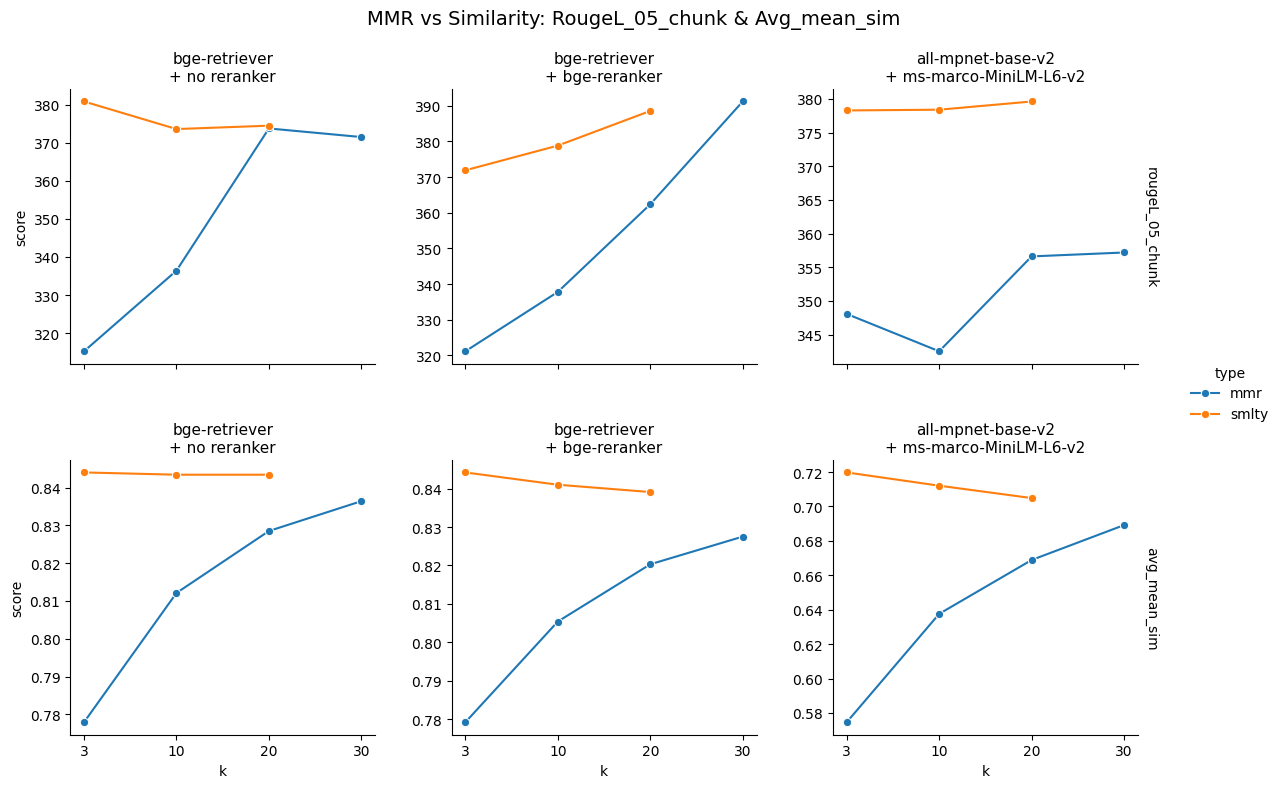

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 计算新指标
df_core = df_combined[[
    "group", "type", "k",
    "rougeL_08_chunk",
    "rougeL_05_chunk", "avg_mean_sim",
    "avg_words_length", "context_chunk"
]].copy()
df_core["words_x_context"] = df_core["avg_words_length"] * df_core["context_chunk"]

# 🔹 只保留同时包含 "mmr" 和 "smlty" 的 group
df_core = df_core.groupby("group").filter(lambda x: set(x["type"]) >= {"mmr", "smlty"})

# melt 成 tidy 格式
df_melt = df_core.melt(
    id_vars=["group", "type", "k"],
    # value_vars=["rougeL_05_chunk", "avg_mean_sim", "words_x_context"],
    value_vars=["rougeL_05_chunk", "avg_mean_sim"],
    var_name="metric",
    value_name="score"
)

# 分面绘图
g = sns.FacetGrid(
    df_melt,
    col="group",
    row="metric",
    hue="type",
    height=4,
    sharey=False,
    margin_titles=True
)
g.map_dataframe(sns.lineplot, x="k", y="score", marker="o")
g.add_legend()


def format_group_title(title: str) -> str:
    # 去掉 seaborn 自动加的 'group = ' 前缀
    title = title.replace("group = ", "")
    # 在第一个 '+' 之前换行
    if '+' in title:
        parts = title.split('+', 1)
        title = parts[0].strip() + "\n+ " + parts[1].strip()
    return title

g.set_titles(col_template="{col_var}", row_template="{row_name}")
for ax, title in zip(g.axes.flat, g.col_names * len(g.row_names)):
    ax.set_title(format_group_title(title), fontsize=11)

# 调整标题和布局
g.figure.subplots_adjust(top=0.88, hspace=0.35, wspace=0.25)
g.figure.suptitle("MMR vs Similarity: RougeL_05_chunk & Avg_mean_sim", fontsize=14)

plt.show()

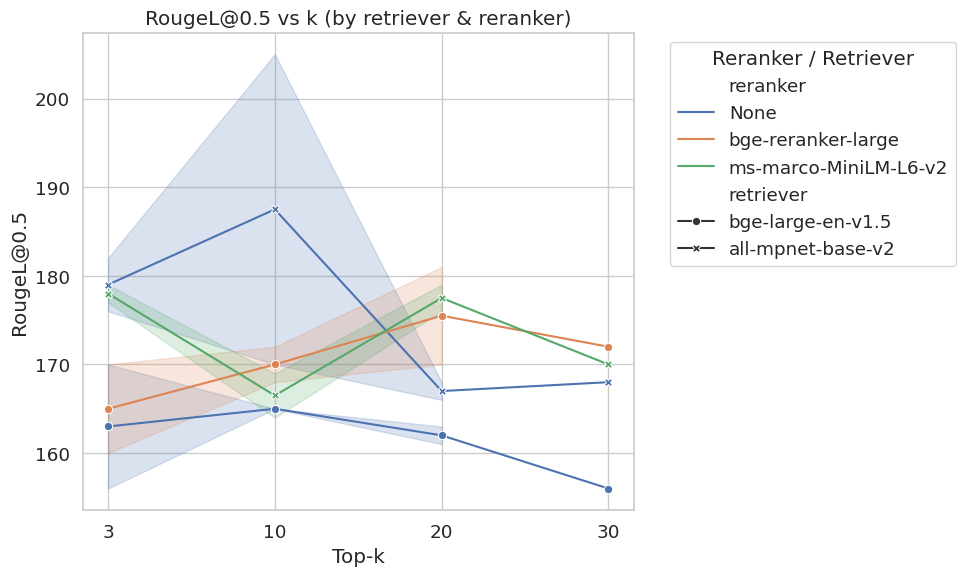

/tmp/ipykernel_301461/3742141072.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


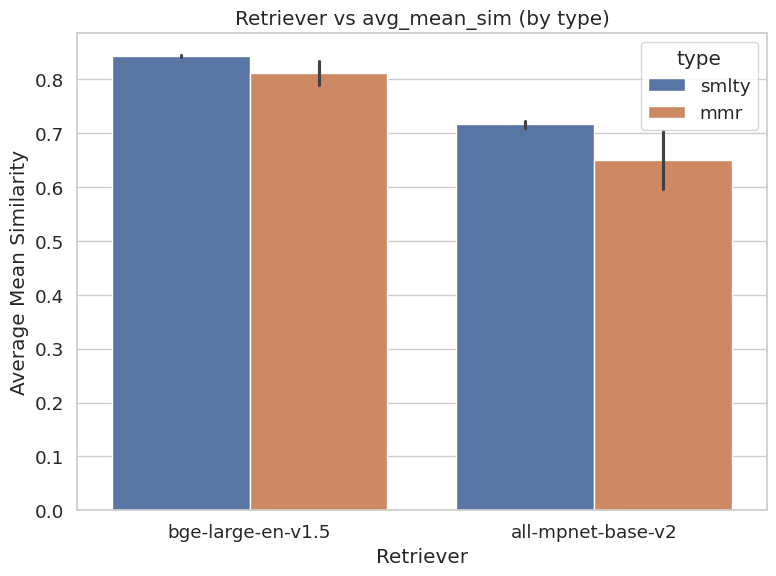

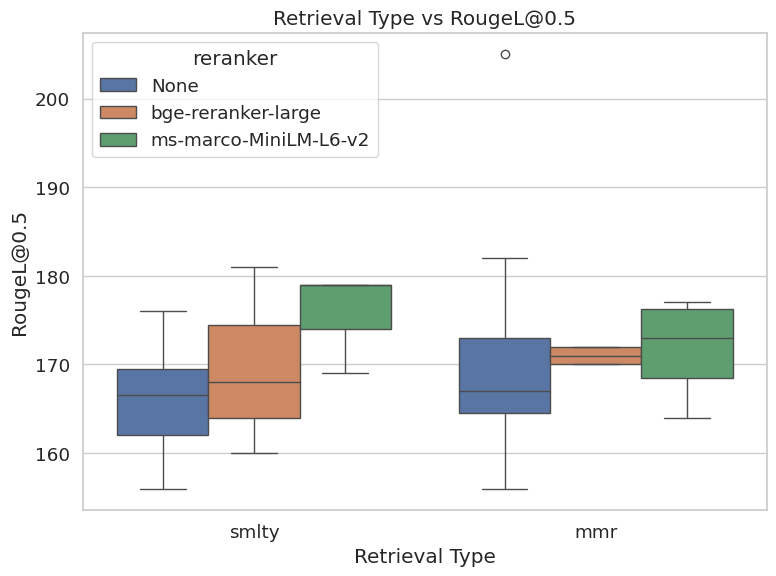

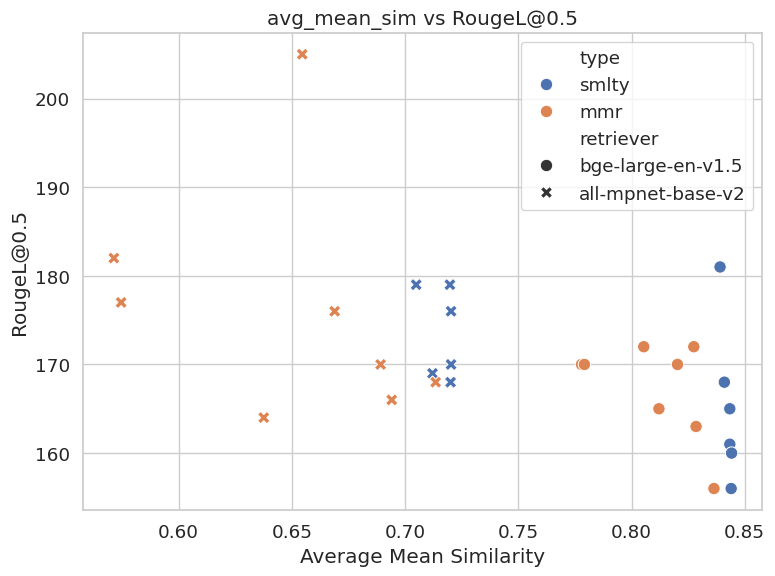

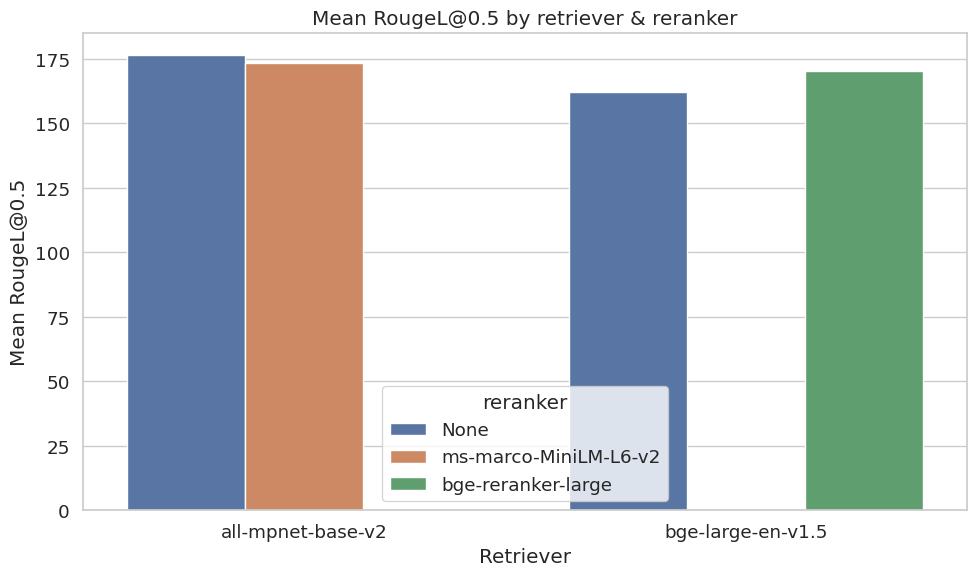

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use clean seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# ==========================================
# 1️⃣ k vs RougeL (by retriever & reranker)
# ==========================================
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x="k",
    y="rougeL_05_prompt",
    hue="reranker",
    style="retriever",
    markers=True,
    dashes=False
)
plt.title("RougeL@0.5 vs k (by retriever & reranker)")
plt.xlabel("Top-k")
plt.ylabel("RougeL@0.5")
plt.legend(title="Reranker / Retriever", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ==========================================
# 2️⃣ Retriever vs avg_mean_sim (by type)
# ==========================================
plt.figure(figsize=(8,6))
sns.barplot(
    data=df,
    x="retriever",
    y="avg_mean_sim",
    hue="type",
    ci="sd"
)
plt.title("Retriever vs avg_mean_sim (by type)")
plt.xlabel("Retriever")
plt.ylabel("Average Mean Similarity")
plt.tight_layout()
plt.show()


# ==========================================
# 3️⃣ Type vs RougeL (by reranker)
# ==========================================
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="type",
    y="rougeL_05_prompt",
    hue="reranker"
)
plt.title("Retrieval Type vs RougeL@0.5")
plt.xlabel("Retrieval Type")
plt.ylabel("RougeL@0.5")
plt.tight_layout()
plt.show()


# ==========================================
# 4️⃣ avg_mean_sim vs RougeL (correlation)
# ==========================================
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="avg_mean_sim",
    y="rougeL_05_prompt",
    hue="type",
    style="retriever",
    s=80
)
plt.title("avg_mean_sim vs RougeL@0.5")
plt.xlabel("Average Mean Similarity")
plt.ylabel("RougeL@0.5")
plt.tight_layout()
plt.show()


# ==========================================
# 5️⃣ Mean RougeL by retriever and reranker
# ==========================================
plt.figure(figsize=(10,6))
reranker_mean = (
    df.groupby(["retriever", "reranker"])["rougeL_05_prompt"]
    .mean()
    .reset_index()
)
sns.barplot(
    data=reranker_mean,
    x="retriever",
    y="rougeL_05_prompt",
    hue="reranker"
)
plt.title("Mean RougeL@0.5 by retriever & reranker")
plt.xlabel("Retriever")
plt.ylabel("Mean RougeL@0.5")
plt.tight_layout()
plt.show()

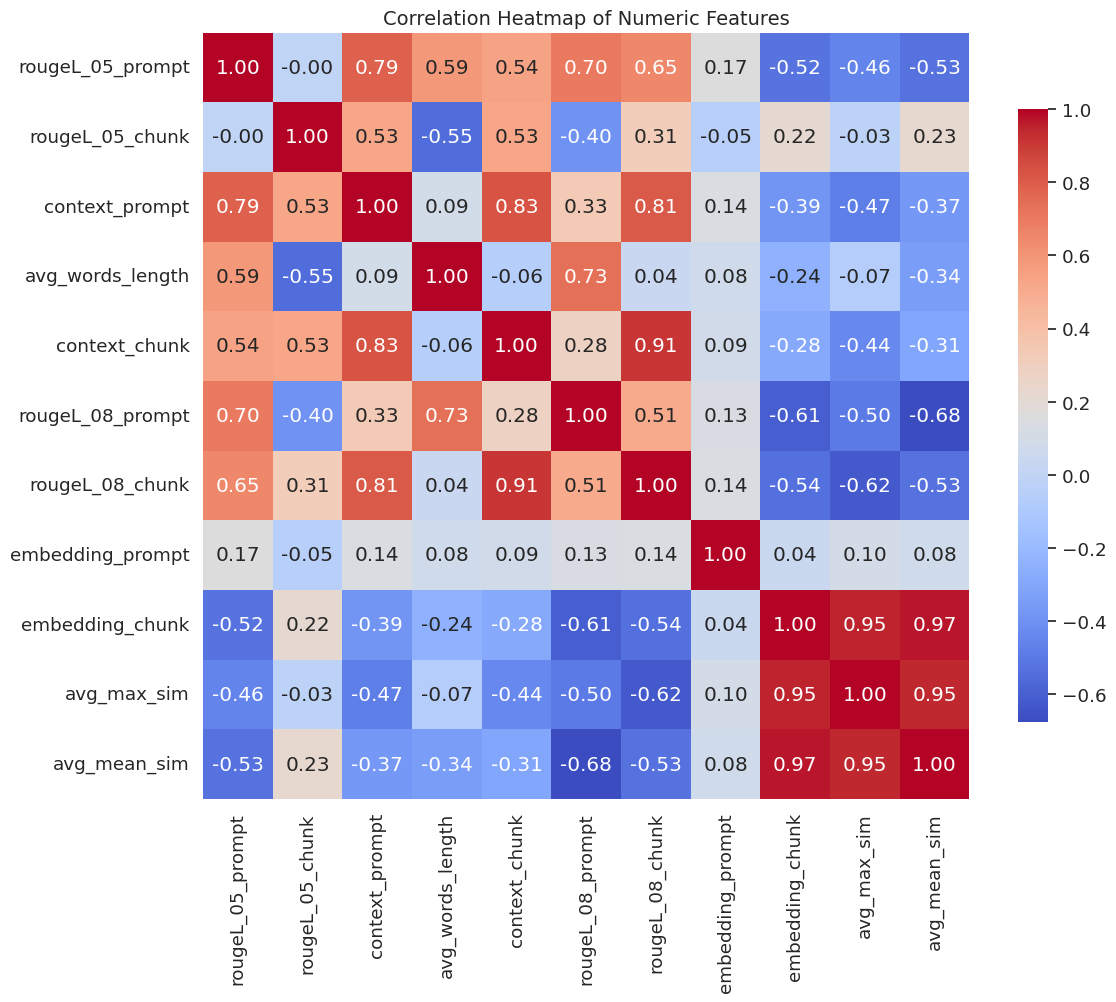

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=["number"])

# Compute correlation matrix
corr = numeric_df.corr()

# Set up the figure
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,        # show correlation values
    fmt=".2f",         # number format
    cmap="coolwarm",   # color map
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()